# Import library

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import string
import joblib

from nltk.corpus import stopwords 
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

# Data Setup

In [3]:
#Path of the file to read 
file_path = 'dataset/raw/email_spam.csv'
df = pd.read_csv(file_path)
#Load dataset
print(df.head())
df.shape

                                                text  spam
0  Subject: naturally irresistible your corporate...     1
1  Subject: the stock trading gunslinger  fanny i...     1
2  Subject: unbelievable new homes made easy  im ...     1
3  Subject: 4 color printing special  request add...     1
4  Subject: do not have money , get software cds ...     1


(5728, 2)

In [4]:
#check data set info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 89.6 KB


# Data cleaning 

In [5]:
#check and handling missing values in dataset
df.isnull().sum()

text    0
spam    0
dtype: int64

In [6]:
# checking for duplicate
print("Total rows:", len(df))
print("Duplicated rows:", df.duplicated().sum())

# % duplicated
print(f"% duplicated: {df.duplicated().sum()/len(df)*100:.2f}%")

Total rows: 5728
Duplicated rows: 33
% duplicated: 0.58%


In [7]:
#remove duplicated rows and unneeded indexes
df.drop_duplicates(inplace=True)
df.reset_index(inplace=True, drop=True)

In [8]:
#check again for no duplicated rows
df.duplicated().sum()

np.int64(0)

# Data Visulization

In [9]:
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [10]:
spam_count = df['spam'].value_counts()
print(spam_count)

spam
0    4327
1    1368
Name: count, dtype: int64


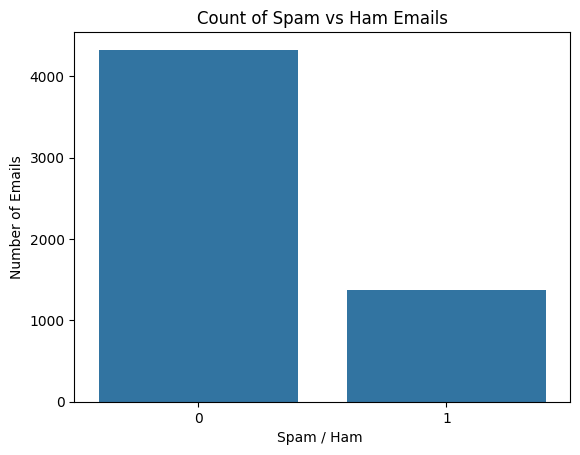

In [11]:
#bar chart: count of spam vs ham
sns.countplot(x=df['spam'])
plt.title("Count of Spam vs Ham Emails")
plt.xlabel("Spam / Ham ")
plt.ylabel("Number of Emails")
plt.show()

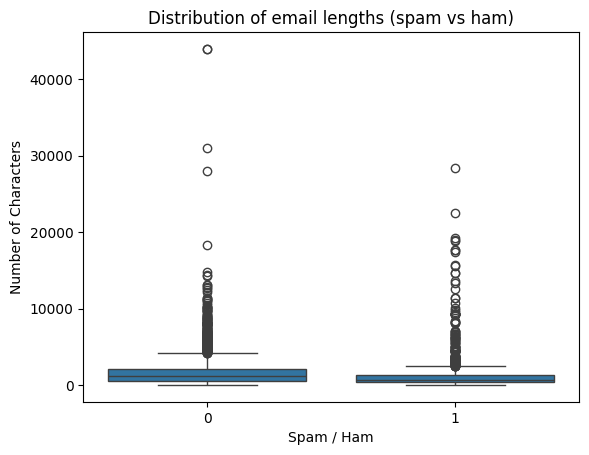

In [12]:
# boxplot: email length by class
df['num_characters'] = df['text'].str.len()
sns.boxplot(x='spam', y='num_characters', data=df)
plt.title("Distribution of email lengths (spam vs ham)")
plt.xlabel("Spam / Ham")
plt.ylabel("Number of Characters")
plt.show()

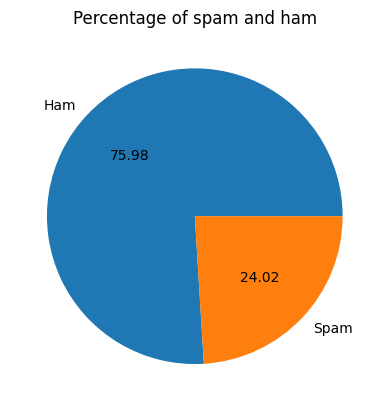

In [13]:
#pie chart: percentage of ham and spam
plt.pie(spam_count, labels=['Ham', 'Spam'], autopct='%0.2f')
plt.title('Percentage of spam and ham')
plt.show()

In [14]:
#number of char
df['num_characters']
df.head()

,text,spam,num_characters
0,Subject: naturally irresistible your corporate...,1,1484
1,Subject: the stock trading gunslinger fanny i...,1,598
2,Subject: unbelievable new homes made easy im ...,1,448
3,Subject: 4 color printing special request add...,1,500
4,"Subject: do not have money , get software cds ...",1,235


In [15]:
#download package punkt
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\Mai
[nltk_data]     Nguyen\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [16]:
#word count
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df.head()


,text,spam,num_characters,num_words
0,Subject: naturally irresistible your corporate...,1,1484,325
1,Subject: the stock trading gunslinger fanny i...,1,598,90
2,Subject: unbelievable new homes made easy im ...,1,448,88
3,Subject: 4 color printing special request add...,1,500,99
4,"Subject: do not have money , get software cds ...",1,235,53


In [17]:
df['num_sen'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head()

,text,spam,num_characters,num_words,num_sen
0,Subject: naturally irresistible your corporate...,1,1484,325,11
1,Subject: the stock trading gunslinger fanny i...,1,598,90,1
2,Subject: unbelievable new homes made easy im ...,1,448,88,4
3,Subject: 4 color printing special request add...,1,500,99,5
4,"Subject: do not have money , get software cds ...",1,235,53,9


In [18]:
df[['num_characters', 'num_words', 'num_sen']].describe()

,num_characters,num_words,num_sen
count,5695.000000,5695.000000,5695.000000
mean,1558.067076,328.214047,19.462511
std,2047.078711,419.654234,35.981993
min,13.000000,3.000000,1.000000
25%,508.500000,102.000000,7.000000
50%,979.000000,211.000000,12.000000
75%,1893.000000,403.000000,22.000000
max,43952.000000,8479.000000,1565.000000


In [19]:
#ham
df[df['spam'] == 0][['num_characters', 'num_words','num_sen']].describe()

,num_characters,num_words,num_sen
count,4327.000000,4327.000000,4327.000000
mean,1634.200139,347.283799,19.838225
std,1965.016383,407.227757,38.124564
min,13.000000,3.000000,1.000000
25%,577.500000,120.000000,7.000000
50%,1122.000000,240.000000,13.000000
75%,2037.500000,440.500000,22.000000
max,43952.000000,8479.000000,1565.000000


In [20]:
#spam
df[df['spam'] == 1][['num_characters', 'num_words', 'num_sen']].describe()

,num_characters,num_words,num_sen
count,1368.000000,1368.000000,1368.000000
mean,1317.257310,267.896199,18.274123
std,2271.372893,451.623124,28.130434
min,18.000000,5.000000,1.000000
25%,401.500000,80.000000,6.000000
50%,693.500000,141.000000,11.000000
75%,1250.250000,252.000000,18.000000
max,28432.000000,6131.000000,438.000000


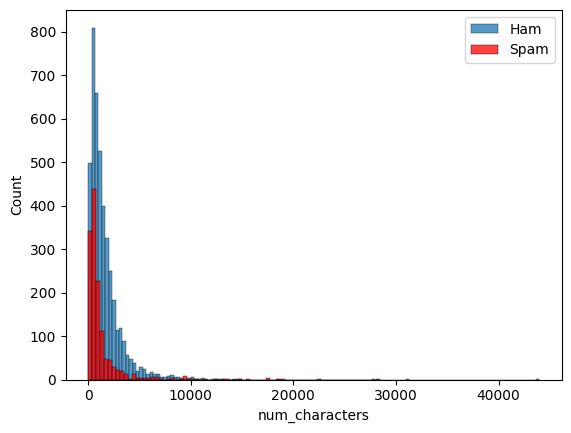

In [21]:
plt.Figure(figsize=(12,6))
sns.histplot(df[df['spam'] == 0]['num_characters'], label ='Ham')
sns.histplot(df[df['spam'] == 1]['num_characters'], label ='Spam', color='red')
plt.legend()

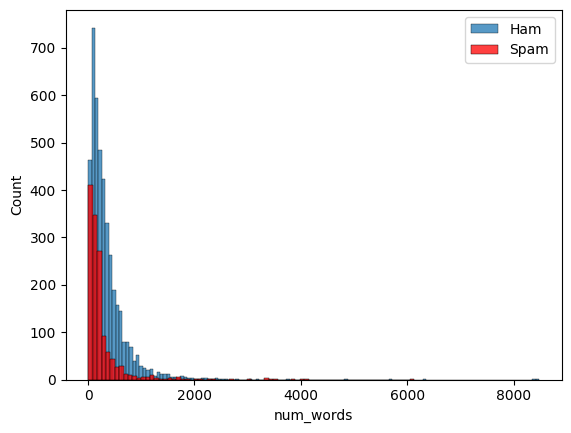

In [22]:
plt.Figure(figsize=(12,6))
sns.histplot(df[df['spam'] == 0]['num_words'], label ='Ham')
sns.histplot(df[df['spam'] == 1]['num_words'], label = 'Spam', color='red')
plt.legend()

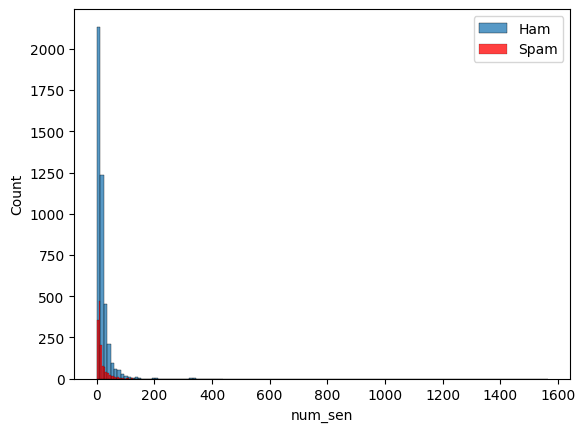

In [23]:
plt.Figure(figsize=(12,6))
sns.histplot(df[df['spam'] == 0]['num_sen'], label = 'Ham')
sns.histplot(df[df['spam'] == 1]['num_sen'], label ='Spam', color='red')
plt.legend()

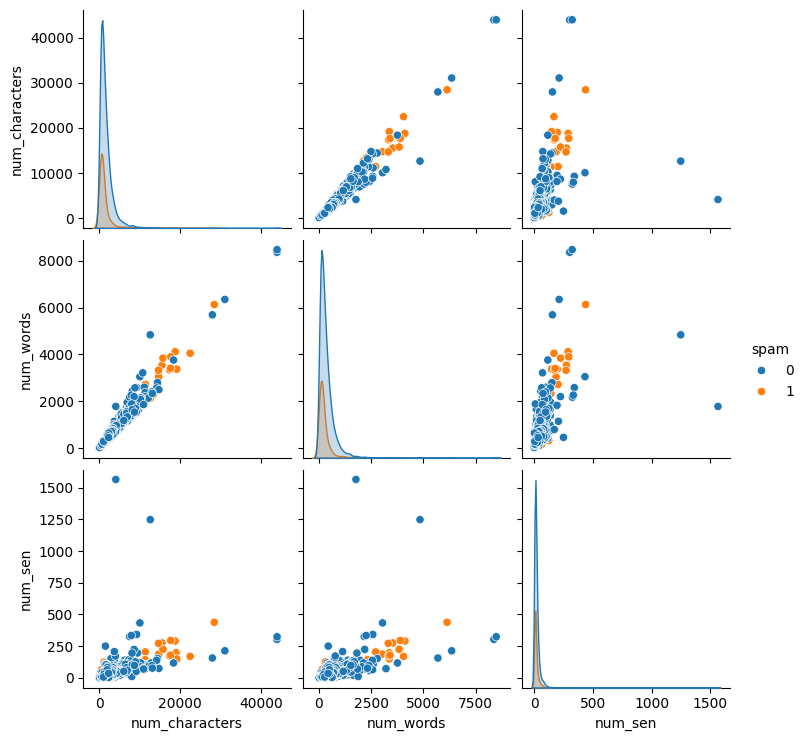

In [24]:
sns.pairplot(df,hue = 'spam')

# Data Preprocessing

In [25]:
#download the stopwords 
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Mai
[nltk_data]     Nguyen\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
import nltk
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

def transform_text(text):
    text = text.lower() #lowercase the words
    text = nltk.word_tokenize(text) #tokenize the test into a single word

    #remove special characters
    y = []
    for i in text:
        if i .isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    #remove stopwords
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    text = y[:]
    y.clear()

    #apply stemming to return the root form
    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

#test
test = transform_text ("i'm going hone")
print(test)

go hone


In [27]:
df['transformed_text'] = df['text'].apply(transform_text)

In [28]:
df.head()

,text,spam,num_characters,num_words,num_sen,transformed_text
0,Subject: naturally irresistible your corporate...,1,1484,325,11,subject natur irresist corpor ident lt realli ...
1,Subject: the stock trading gunslinger fanny i...,1,598,90,1,subject stock trade gunsling fanni merril muzo...
2,Subject: unbelievable new homes made easy im ...,1,448,88,4,subject unbeliev new home made easi im want sh...
3,Subject: 4 color printing special request add...,1,500,99,5,subject 4 color print special request addit in...
4,"Subject: do not have money , get software cds ...",1,235,53,9,subject money get softwar cd softwar compat gr...


In [29]:
#save the processed data
df.to_csv('dataset/processed/processed_spam.csv', index=False)

In [30]:
wc = WordCloud(width=800,
               height=400, 
               min_font_size =10,
               background_color='white')

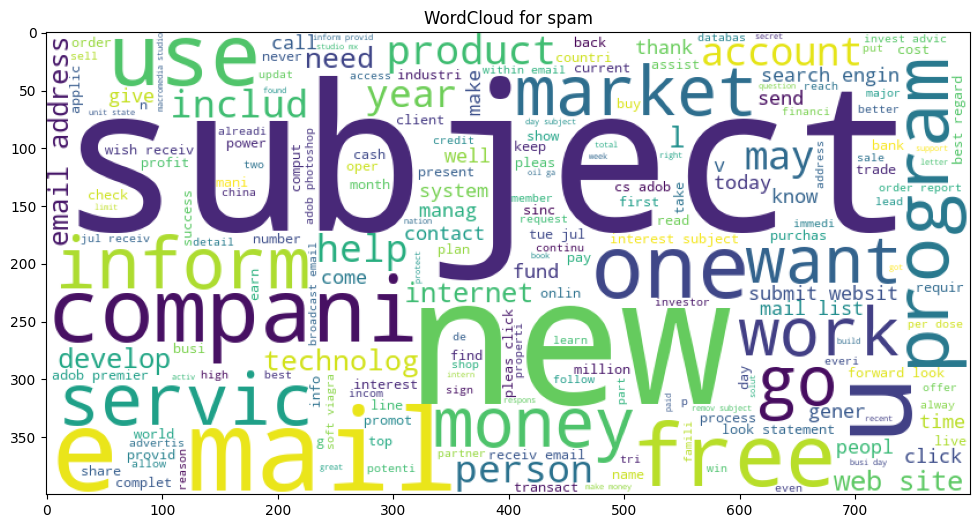

In [31]:
#wordcloud for spam
spam_text = df[df['spam'] == 1]['transformed_text'].str.cat(sep=" ")

wc = WordCloud(width=800, height=400, background_color='white').generate(spam_text)

plt.figure(figsize=(15,6))
plt.title('WordCloud for spam')
plt.imshow(wc)
plt.show()

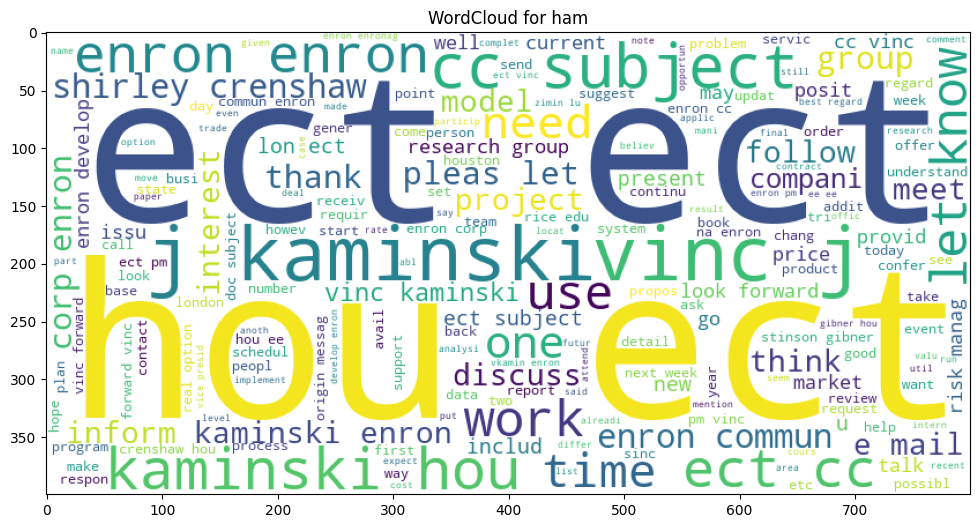

In [32]:
#wordcloud for ham
ham_text = df[df['spam'] == 0]['transformed_text'].str.cat(sep=" ")

wc = WordCloud(width=800, height=400, background_color='white').generate(ham_text)

plt.figure(figsize=(15,6))
plt.title('WordCloud for ham')
plt.imshow(wc)
plt.show()

In [33]:
df.head()

,text,spam,num_characters,num_words,num_sen,transformed_text
0,Subject: naturally irresistible your corporate...,1,1484,325,11,subject natur irresist corpor ident lt realli ...
1,Subject: the stock trading gunslinger fanny i...,1,598,90,1,subject stock trade gunsling fanni merril muzo...
2,Subject: unbelievable new homes made easy im ...,1,448,88,4,subject unbeliev new home made easi im want sh...
3,Subject: 4 color printing special request add...,1,500,99,5,subject 4 color print special request addit in...
4,"Subject: do not have money , get software cds ...",1,235,53,9,subject money get softwar cd softwar compat gr...


In [34]:
spam_corpus = []

for msg in df[df['spam']==1]['transformed_text']:
    for word in msg.split():
        spam_corpus.append(word)

In [35]:
len(spam_corpus)

174630

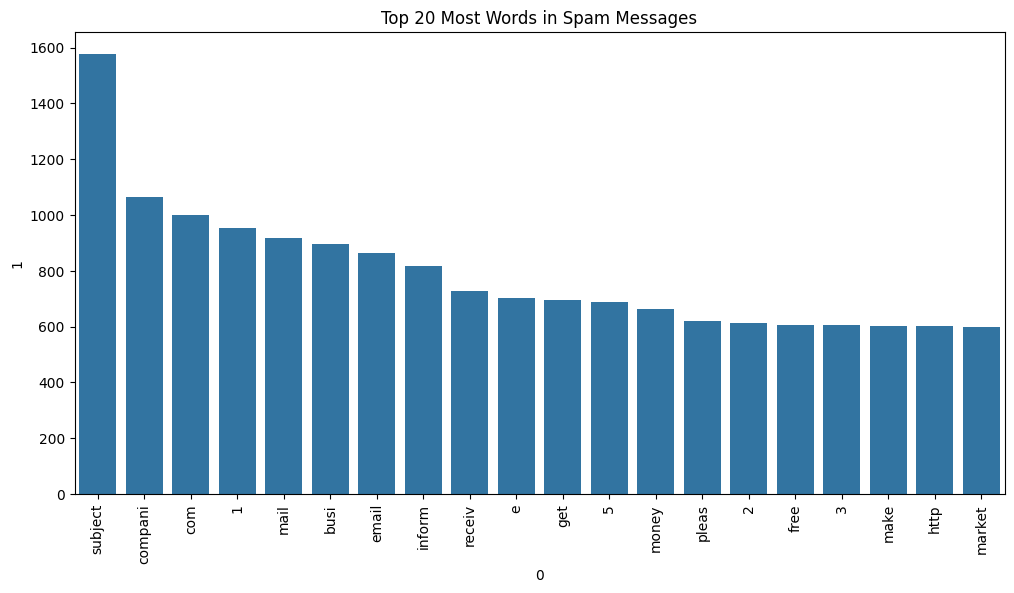

In [36]:
#histogram for keyword spam count
top_words = pd.DataFrame(Counter(spam_corpus).most_common(20))

plt.figure(figsize=(12,6))
sns.barplot(x=top_words[0], y=top_words[1])
plt.title('Top 20 Most Words in Spam Messages')
plt.xticks(rotation='vertical')
plt.show()

In [37]:
ham_corpus = []

for msg in df[df['spam'] == 0]['transformed_text']:
    for word in msg.split():
        ham_corpus.append(word)

In [38]:
len(ham_corpus)


702991

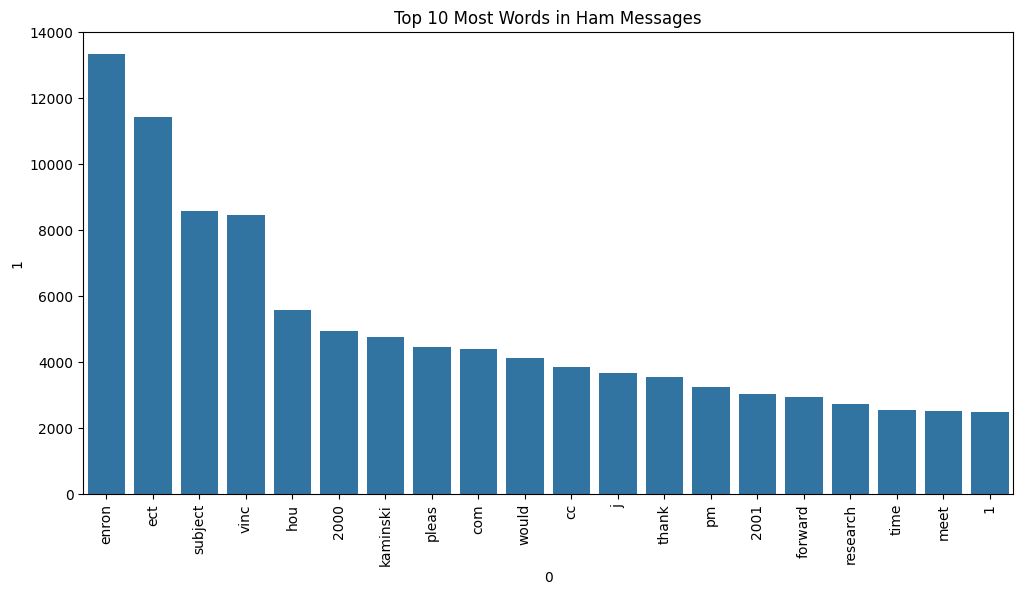

In [39]:
#histogram for keyword ham count
top_words = pd.DataFrame(Counter(ham_corpus).most_common(20))

plt.figure(figsize=(12,6))
sns.barplot(x=top_words[0], y=top_words[1])
plt.title('Top 10 Most Words in Ham Messages')
plt.xticks(rotation='vertical')
plt.show()

# Feature Extraction 

In [40]:
# X is the text, y is the label ( spam or ham)
X = df['transformed_text']
y = df['spam']

#split the text and label into training (70%) and test (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, shuffle=True, random_state=42)

#check the number of samples in training and testing sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3986,), (1709,), (3986,), (1709,))

In [41]:
# Turns text into Tf-IDF feature (use single words to scale vectors)
tfidf_vectorizer = TfidfVectorizer( analyzer='word', ngram_range=(1, 1))

X_strain = tfidf_vectorizer.fit_transform(X_train)
X_stest = tfidf_vectorizer.transform(X_test)

X_strain.shape, X_stest.shape

((3986, 24812), (1709, 24812))

# Model Training

In [42]:
#Model 1 -  Logistic Regeression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_strain, y_train)

y_pred_lr = lr.predict(X_stest)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9742539496781744
[[1263    6]
 [  38  402]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1269
           1       0.99      0.91      0.95       440

    accuracy                           0.97      1709
   macro avg       0.98      0.95      0.97      1709
weighted avg       0.97      0.97      0.97      1709



In [43]:
#Model 2 — Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_strain, y_train)

y_pred_rf = rf.predict(X_stest)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9742539496781744
[[1268    1]
 [  43  397]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1269
           1       1.00      0.90      0.95       440

    accuracy                           0.97      1709
   macro avg       0.98      0.95      0.97      1709
weighted avg       0.97      0.97      0.97      1709



In [44]:
#show the accuracy of the each model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_rf]
})

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_rf],
    "Precision": [precision_lr, precision_rf],
    "Recall": [recall_lr, recall_rf],
    "F1-score": [f1_lr, f1_rf]
})

print("\n--- Model Comparison ---")
print(comparison)


--- Model Comparison ---
                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.974254   0.985294  0.913636  0.948113
1        Random Forest  0.974254   0.997487  0.902273  0.947494


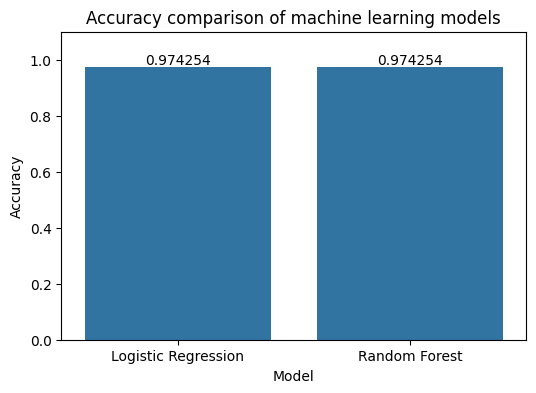

In [45]:
#visulization for accuracy comparision
plt.figure(figsize=(6,4))

ax = sns.barplot(x="Model", y="Accuracy", data=comparison)

for container in ax.containers:
    ax.bar_label(container, fmt="%.6f")

plt.title("Accuracy comparison of machine learning models")
plt.ylim(0,1.1)

plt.show()

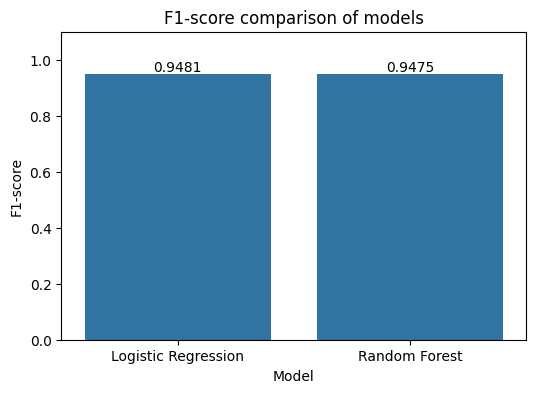

In [46]:
#visulization for F1-score comparision
plt.figure(figsize=(6,4))

ax = sns.barplot(x="Model", y="F1-score", data=comparison)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f")

plt.title("F1-score comparison of models")
plt.ylim(0,1.1)

plt.show()

# Save Model

In [47]:
joblib.dump(rf, "backend/model/email_spam_rf_model.pkl") #save model random forest
joblib.dump(tfidf_vectorizer, "backend/model/vectorizer.pkl")

['backend/model/vectorizer.pkl']

In [48]:
#test model
samples = [
    "Win a FREE iPhone now!!!",
    "Hey, are we meeting today?",
    "Congratulations, you won money!!!"
]

for text in samples:
    vec = tfidf_vectorizer.transform([text])
    pred = rf.predict(vec)[0]
    print(f"{text} → {'Spam' if pred == 1 else 'Not Spam'}")

Win a FREE iPhone now!!! → Not Spam
Hey, are we meeting today? → Not Spam
Congratulations, you won money!!! → Not Spam
